# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from src.config import load_default_gene_expression_configs

config1, config2 = load_default_gene_expression_configs('distinct')


todo: Loading testing config from replication deconvolution


In [6]:
from src.deconvolution_solver import DeconvolutionSolver
g = load_gene_expression('DSE4')
H = config1.H

In [7]:
from src.expression_gamma_search import GeneExpressionFindOptimalGamma

expression_find_gamma = GeneExpressionFindOptimalGamma(config=config1, gene_expression=g,
                                                      gamma_min=0.001, gamma_max=0.1)

	Base error (γ=0):	rn: 1.234762	sn: 1350.444079
	Error boundaries:
		Left:
			Relative (1.05 * e0): 1.2965
			Absolute (e0 + 0.04): 1.27476
			Chosen: 1.274762
		Right:
			Relative (4.00 * e0): 4.93905
			Absolute (e0 + 11.00): 12.2348
			Chosen: 12.234762
	Searching for left boundary gamma...
		γ: 0.0505	rn: 12.2300	sn: 4.5238
		γ: 0.02575	rn: 8.9193	sn: 5.1191
		γ: 0.013375	rn: 7.4198	sn: 5.7132
		γ: 0.0071875	rn: 6.9854	sn: 6.0285
		γ: 0.00409375	rn: 6.2135	sn: 6.8579
		γ: 0.00254688	rn: 5.1108	sn: 9.4165
		γ: 0.00177344	rn: 4.2321	sn: 12.4547
		γ: 0.00138672	rn: 3.8312	sn: 14.3639
		γ: 0.00119336	rn: 3.6522	sn: 15.4161
		γ: 0.00109668	rn: 3.5722	sn: 15.9367
		γ: 0.00104834	rn: 3.5344	sn: 16.1990
		γ: 0.00102417	rn: 3.5213	sn: 16.2942
		γ: 0.00101208	rn: 3.5112	sn: 16.3684
		γ: 0.00100604	rn: 3.5057	sn: 16.4087
		γ: 0.00100302	rn: 3.5029	sn: 16.4289
		γ: 0.00100151	rn: 3.5015	sn: 16.4390
		γ: 0.00100076	rn: 3.5009	sn: 16.4440
	Left boundary gamma found: 0.00100038
	Searching for rig

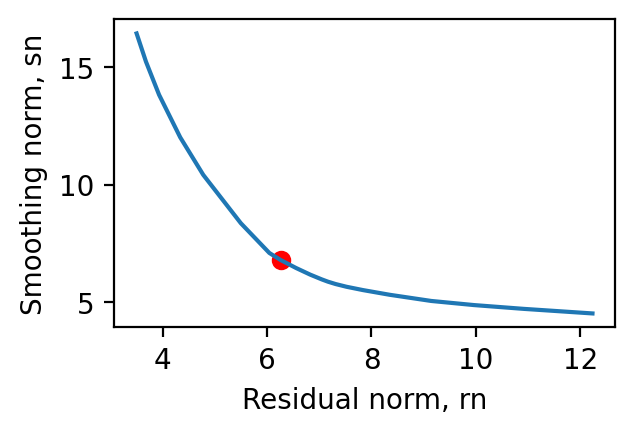

In [8]:
expression_find_gamma.find_optimal_gamma()

	Base error (γ=0):	rn: 0.217129	sn: 1543.124885
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.227985
			Absolute (e0 + 0.04): 0.257129
			Chosen: 0.227985
		Right:
			Relative (4.00 * e0): 0.868515
			Absolute (e0 + 11.00): 11.2171
			Chosen: 11.217129
	Searching for left boundary gamma...
		γ: 0.0505	rn: 2.7726	sn: 3.9558
		γ: 0.02575	rn: 1.8669	sn: 4.1181
		γ: 0.013375	rn: 1.1044	sn: 4.4517
		γ: 0.0071875	rn: 0.7774	sn: 4.7197
		γ: 0.00409375	rn: 0.5950	sn: 4.9893
		γ: 0.00254688	rn: 0.5105	sn: 5.1887
		γ: 0.00177344	rn: 0.4728	sn: 5.3220
		γ: 0.00138672	rn: 0.4609	sn: 5.3768
		γ: 0.00119336	rn: 0.4567	sn: 5.4028
		γ: 0.00109668	rn: 0.4548	sn: 5.4168
		γ: 0.00104834	rn: 0.4536	sn: 5.4271
		γ: 0.00102417	rn: 0.4529	sn: 5.4332
		γ: 0.00101208	rn: 0.4526	sn: 5.4363
		γ: 0.00100604	rn: 0.4524	sn: 5.4378
		γ: 0.00100302	rn: 0.4524	sn: 5.4385
		γ: 0.00100151	rn: 0.4523	sn: 5.4389
		γ: 0.00100076	rn: 0.4523	sn: 5.4391
	Left boundary gamma found: 0.00100038
	Searching for right bound

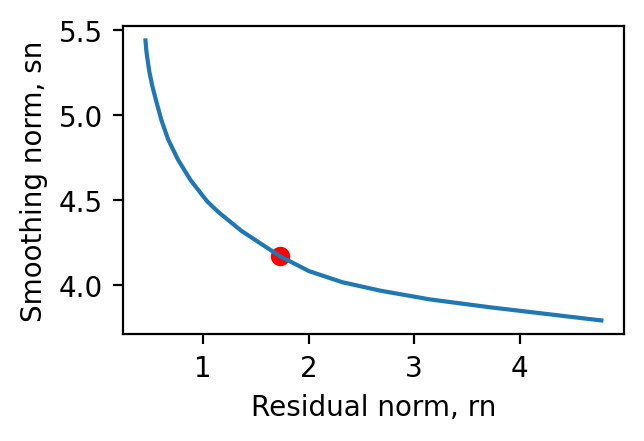

In [1067]:
# from src.expression_gamma_search import GeneExpressionFindOptimalGamma

gene_name = 'SIC1'

g = load_gene_expression(gene_name)
expression_find_gamma = GeneExpressionFindOptimalGamma(config=config1, gene_expression=g,
                                                      gamma_min=0.001, gamma_max=0.1)
expression_find_gamma.find_optimal_gamma(kappa=1e-4)

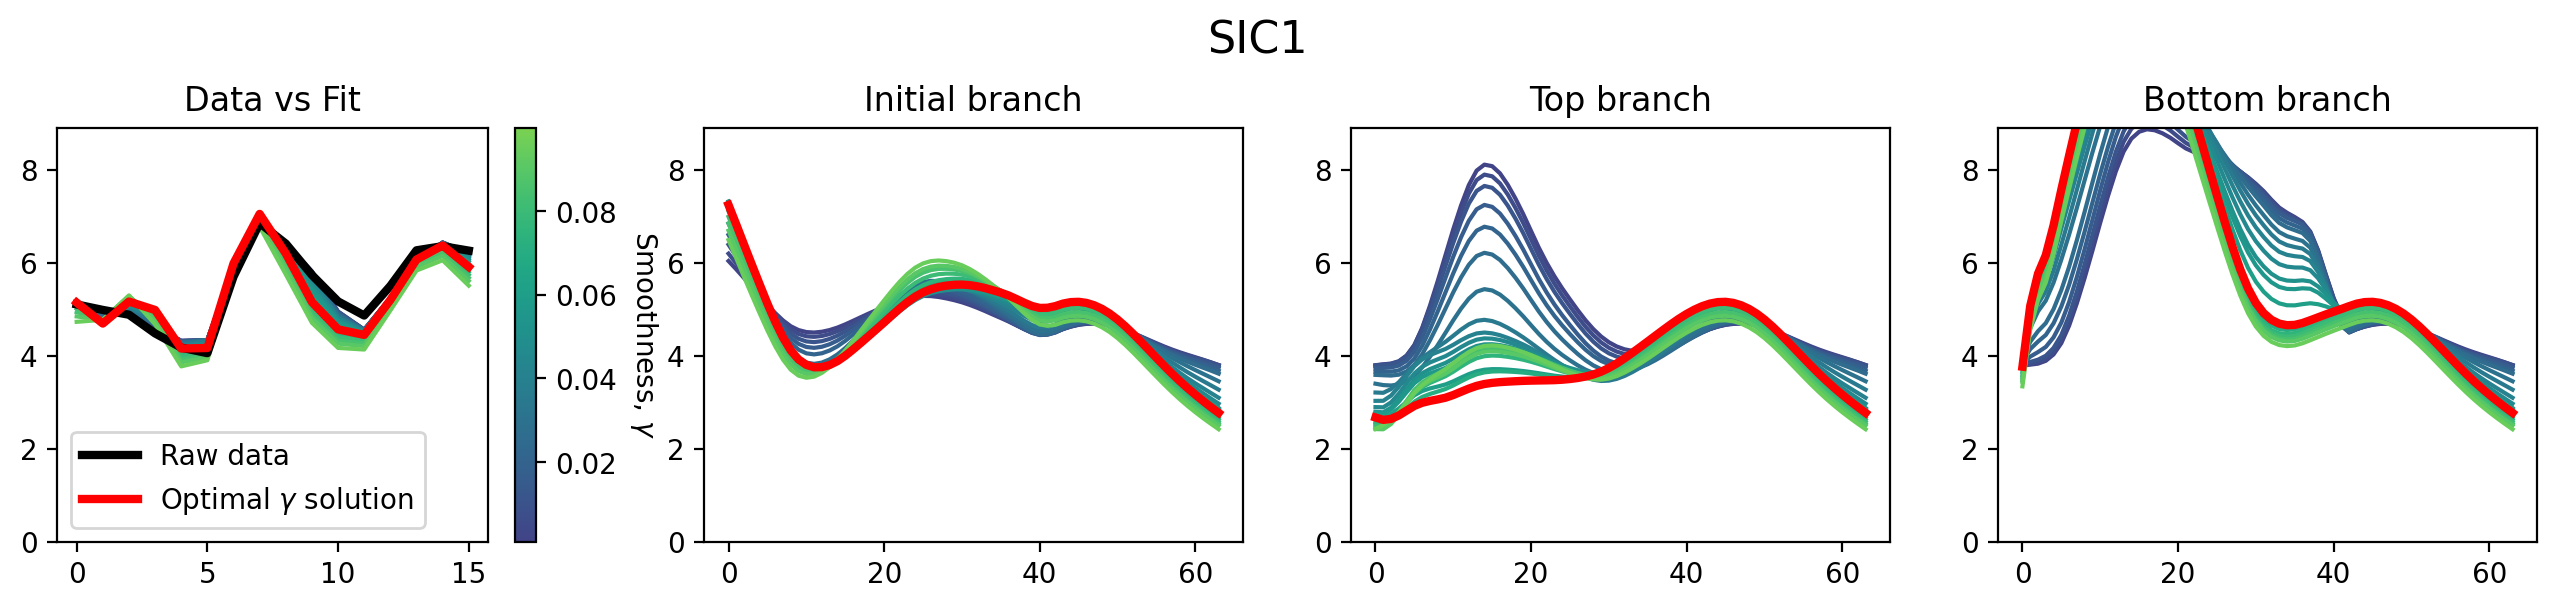

In [1068]:
expression_find_gamma.plot_gamma_sweep()
plt.suptitle(gene_name, fontsize=16)
plt.subplots_adjust(top=0.8)


In [221]:
# Planning - Determine a way to identify an optimal kappa value
# to regularize the mother and daughter branches.
# Goal: Identifies daughter-specific gene expression, without introducing false positive
# gene expression for mothers. Using Guo's published results as a reference point


In [1183]:
from src.find_optimal_kappa import FindKappaExpression
find_kappa = FindKappaExpression(config1)

In [1184]:
find_kappa.sweep_kappas()

[1/20]Kappa= 0.0001
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:01:31.599

[2/20]Kappa= 0.0001438449888287663
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:02:51.229

[3/20]Kappa= 0.00020691380811147902
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:03:58.753

[4/20]Kappa= 0.00029763514416313193
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:05:04.393

[5/20]Kappa= 0.00042813323987193956
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:06:09.763

[6/20]Kappa= 0.0006158482110660267
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:07:16.542

[7/20]Kappa= 0.0008858667904100823
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:08:20.423

[8/20]Kappa= 0.0012742749857031334
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:09:25.792

[9/20]Kappa= 0.0018329807108324356
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,R

In [1221]:
find_kappa.compute_l2tb()

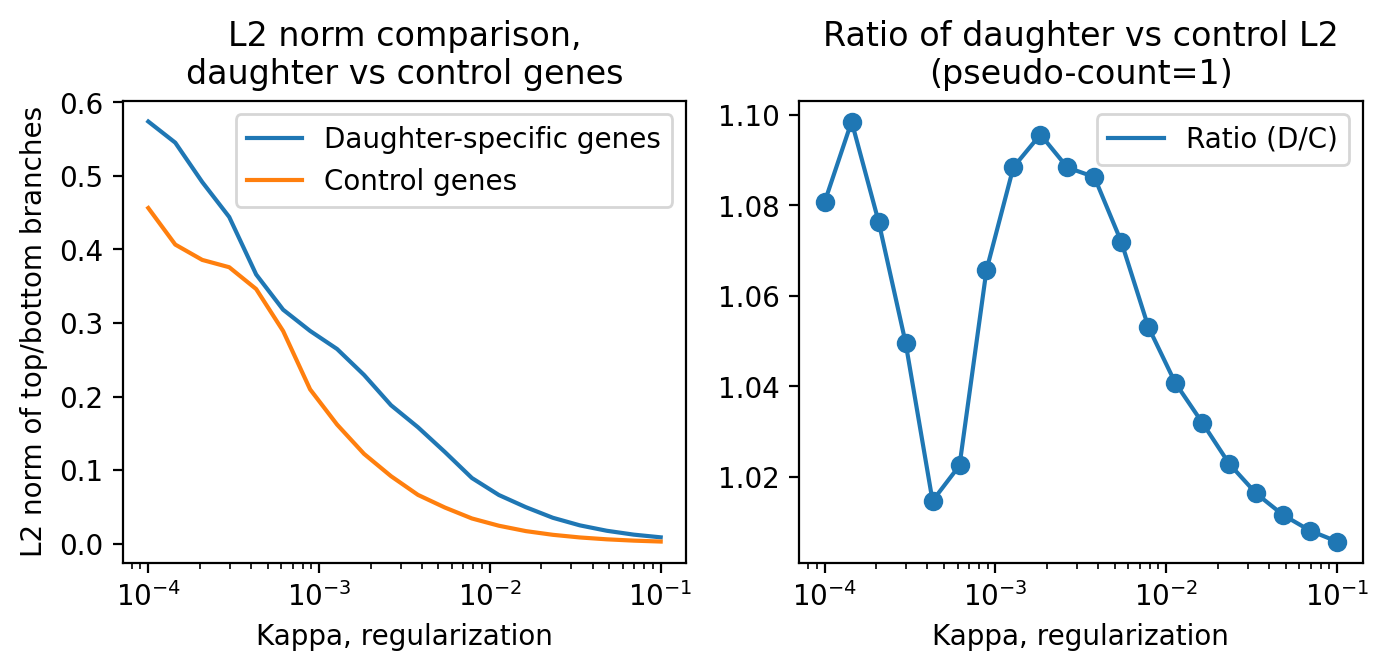

In [1222]:
find_kappa.plot_l2_tb()

In [1220]:
# Skip the first four values and find the argmax
offset = 4
optimal_idx = find_kappa.snr_l2.iloc[offset:].argmax()+offset
optimal = pd.DataFrame(find_kappa.snr_l2).iloc[optimal_idx]
optimal_kappa, optimal_snr = optimal.name, optimal.values[0]
optimal_idx, optimal_kappa

(8, 0.0018329807108324356)

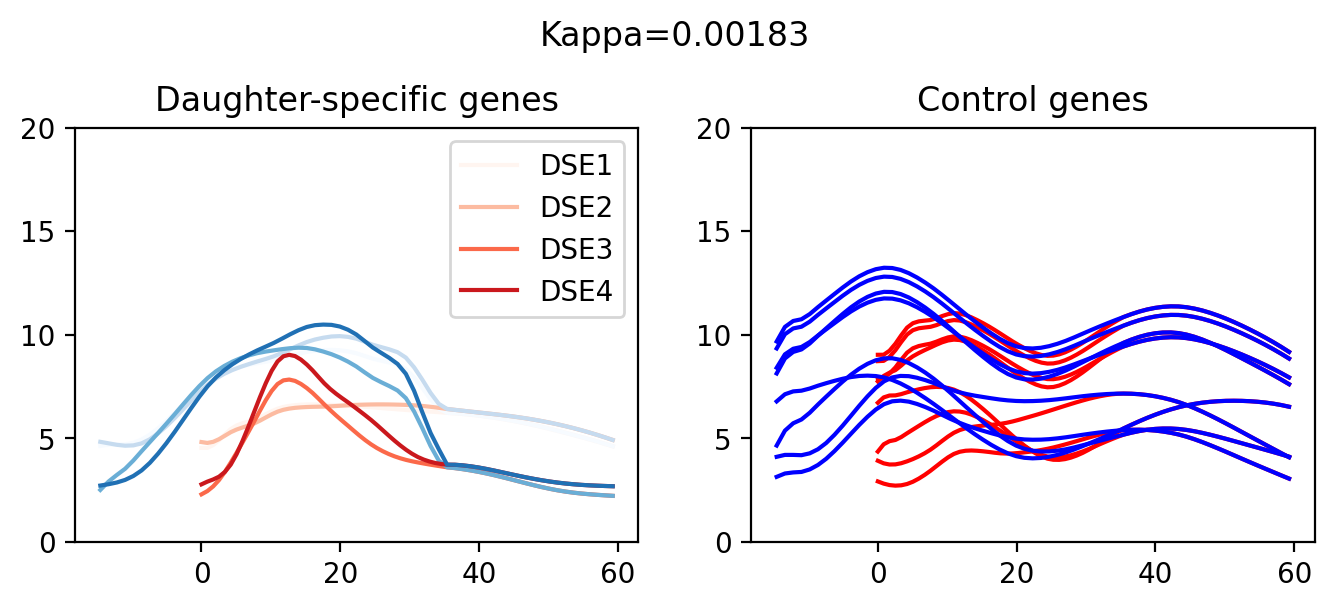

In [1217]:
find_kappa.plot_example_kappa(optimal_idx)

	Base error (γ=0):	rn: 1.002486	sn: 1945.575275
	Error boundaries:
		Left:
			Relative (1.05 * e0): 1.05261
			Absolute (e0 + 0.04): 1.04249
			Chosen: 1.042486
		Right:
			Relative (4.00 * e0): 4.00994
			Absolute (e0 + 11.00): 12.0025
			Chosen: 12.002486
	Searching for left boundary gamma...
		γ: 0.0505	rn: 7.1466	sn: 5.3343
		γ: 0.02575	rn: 4.9844	sn: 5.8226
		γ: 0.013375	rn: 3.3932	sn: 6.4264
		γ: 0.0071875	rn: 2.6978	sn: 6.9989
		γ: 0.00409375	rn: 2.3462	sn: 7.5785
		γ: 0.00254688	rn: 2.1762	sn: 7.9764
		γ: 0.00177344	rn: 2.0377	sn: 8.4918
		γ: 0.00138672	rn: 1.9324	sn: 9.0063
		γ: 0.00119336	rn: 1.8902	sn: 9.2183
		γ: 0.00109668	rn: 1.8700	sn: 9.3253
		γ: 0.00104834	rn: 1.8597	sn: 9.3805
		γ: 0.00102417	rn: 1.8546	sn: 9.4079
		γ: 0.00101208	rn: 1.8521	sn: 9.4216
		γ: 0.00100604	rn: 1.8509	sn: 9.4284
		γ: 0.00100302	rn: 1.8503	sn: 9.4318
		γ: 0.00100151	rn: 1.8500	sn: 9.4335
		γ: 0.00100076	rn: 1.8498	sn: 9.4344
	Left boundary gamma found: 0.00100038
	Searching for right boundary

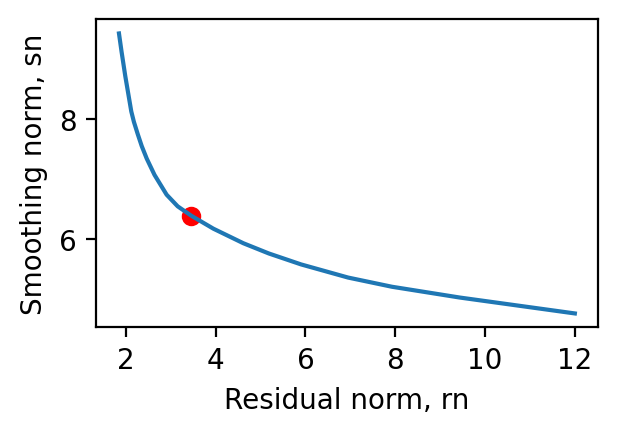

In [1191]:
# from src.expression_gamma_search import GeneExpressionFindOptimalGamma

gene_name = 'DSE1'

g = load_gene_expression(gene_name)
expression_find_gamma = GeneExpressionFindOptimalGamma(config=config1, gene_expression=g,
                                                      gamma_min=0.001, gamma_max=0.1)
expression_find_gamma.find_optimal_gamma(kappa=optimal_kappa)

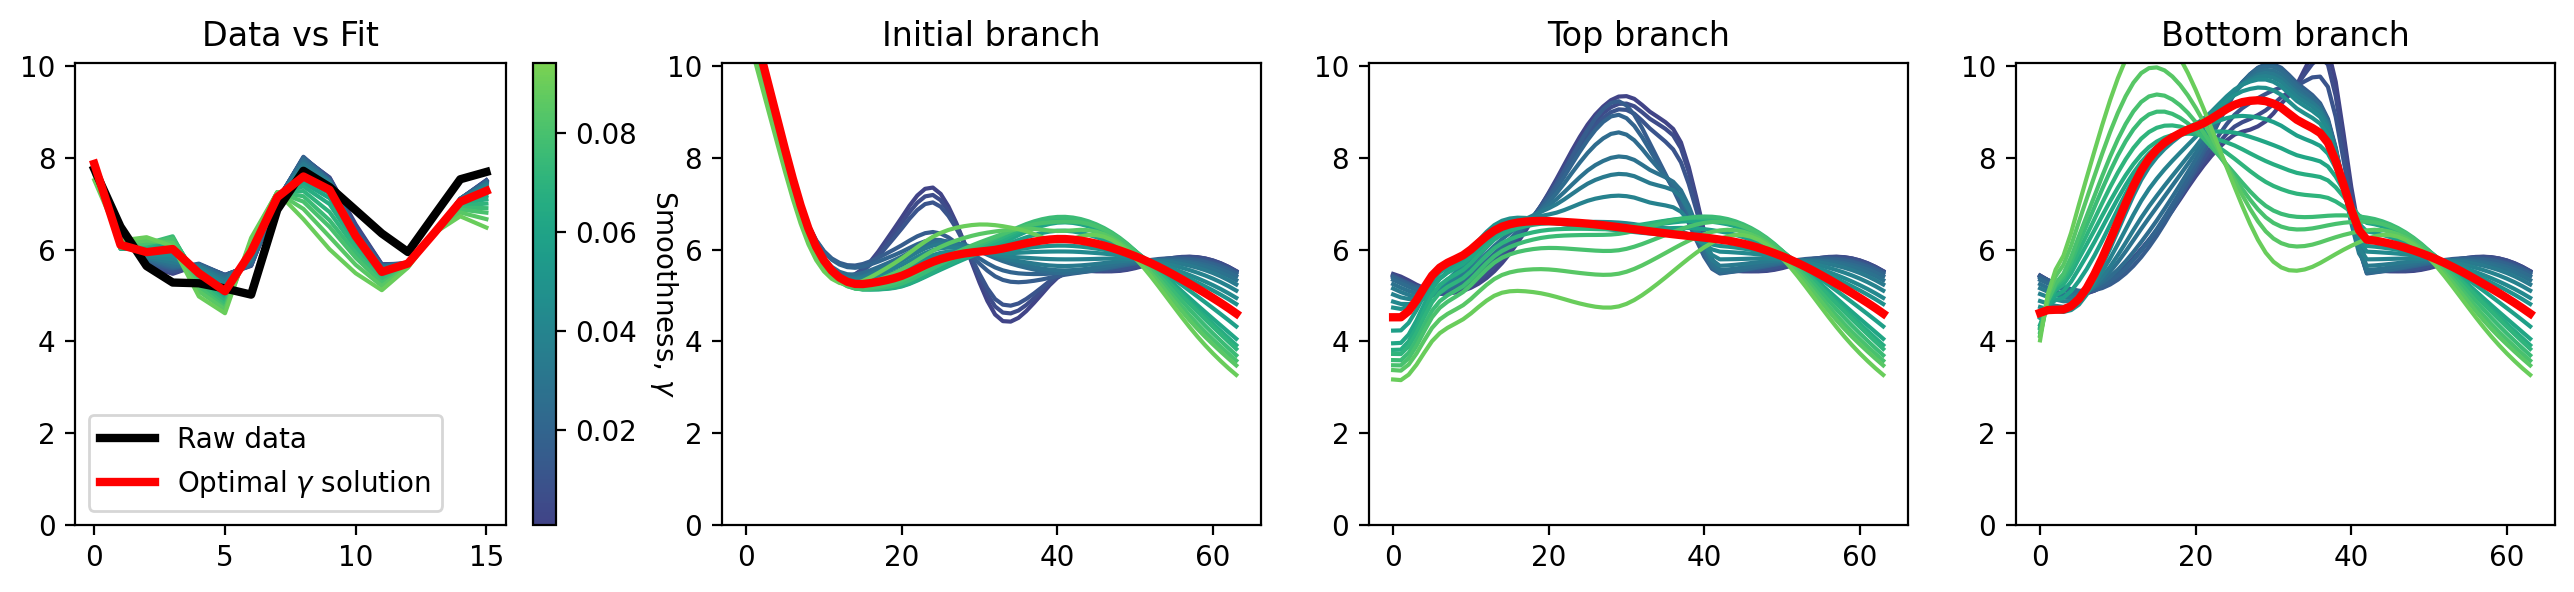

In [1192]:
expression_find_gamma.plot_gamma_sweep()

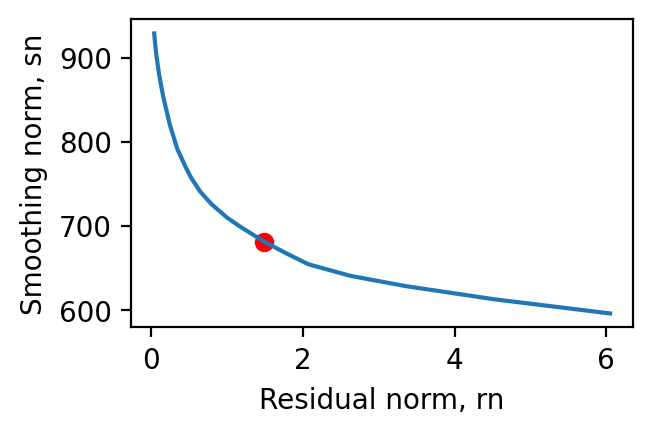

In [1200]:
gene_name = 'MCM6'

g = load_gene_expression(gene_name)
expression_find_gamma = GeneExpressionFindOptimalGamma(config=config1, gene_expression=g,
                                                      gamma_min=0.001, gamma_max=0.1)
expression_find_gamma.find_optimal_gamma(kappa=optimal_kappa, verbose=False)

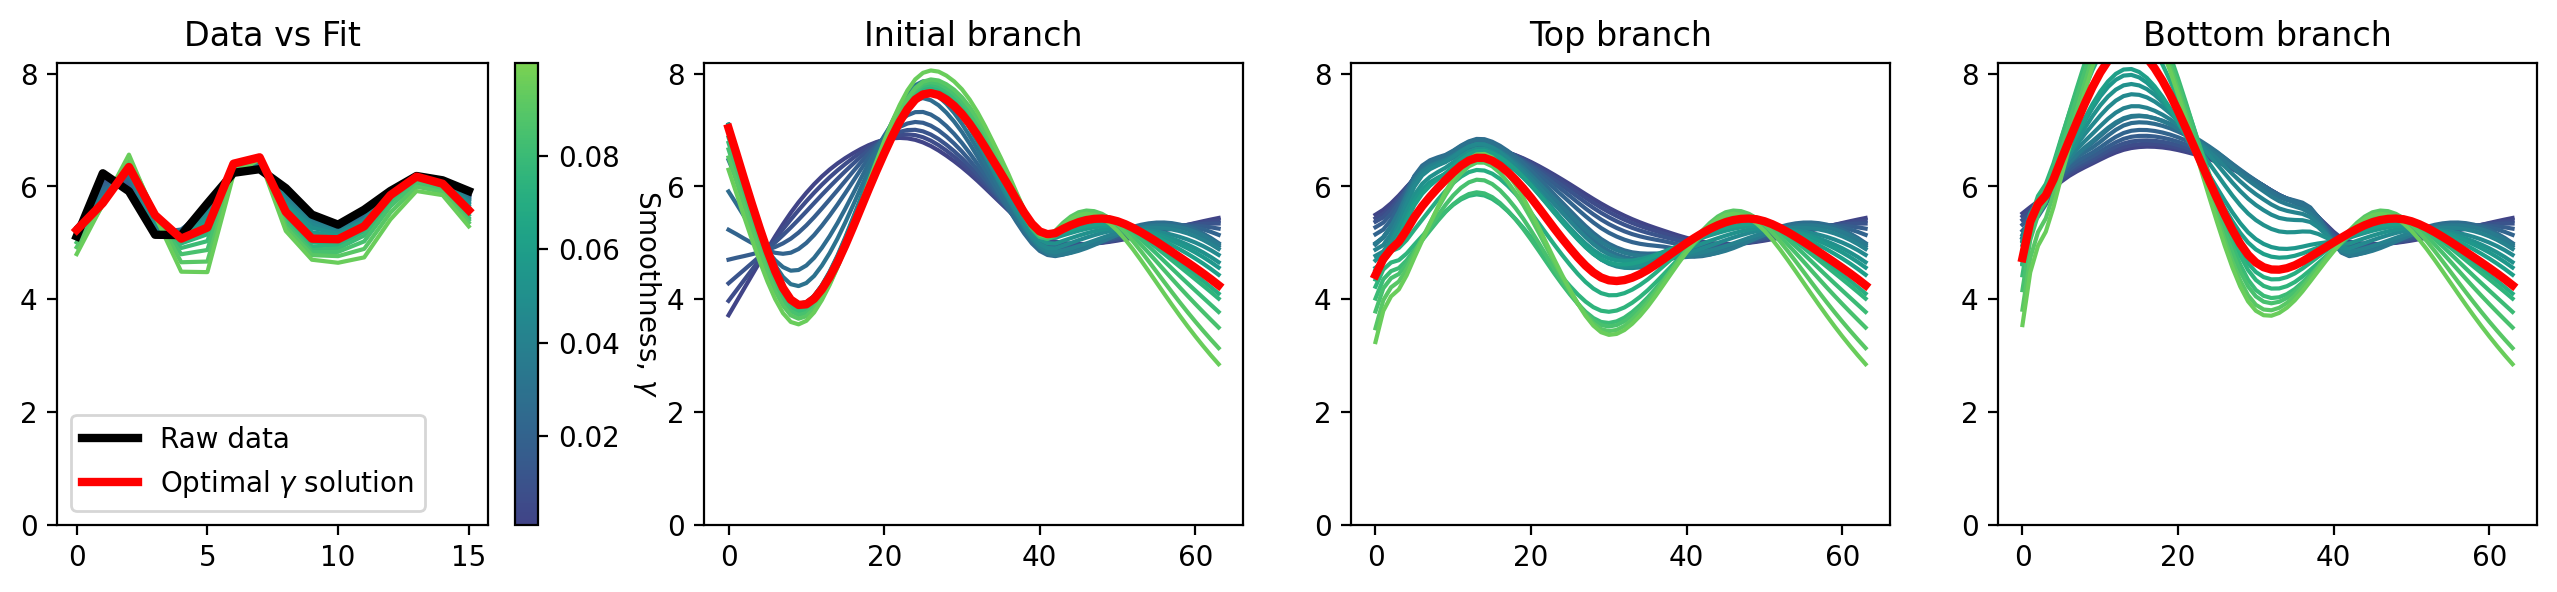

In [1201]:
expression_find_gamma.plot_gamma_sweep()